In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
import os
print(os.getcwd())

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/notebook


In [3]:
df = pd.read_csv("../TSLA.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [6]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.2 KB


In [10]:
df.set_index('Date', inplace=True)

In [11]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [12]:
target = df['Close']

In [13]:
df[['Close', 'Adj Close']].head()

,Close,Adj Close
Date,,
2010-06-29,23.889999,23.889999
2010-06-30,23.830000,23.830000
2010-07-01,21.959999,21.959999
2010-07-02,19.200001,19.200001
2010-07-06,16.110001,16.110001


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


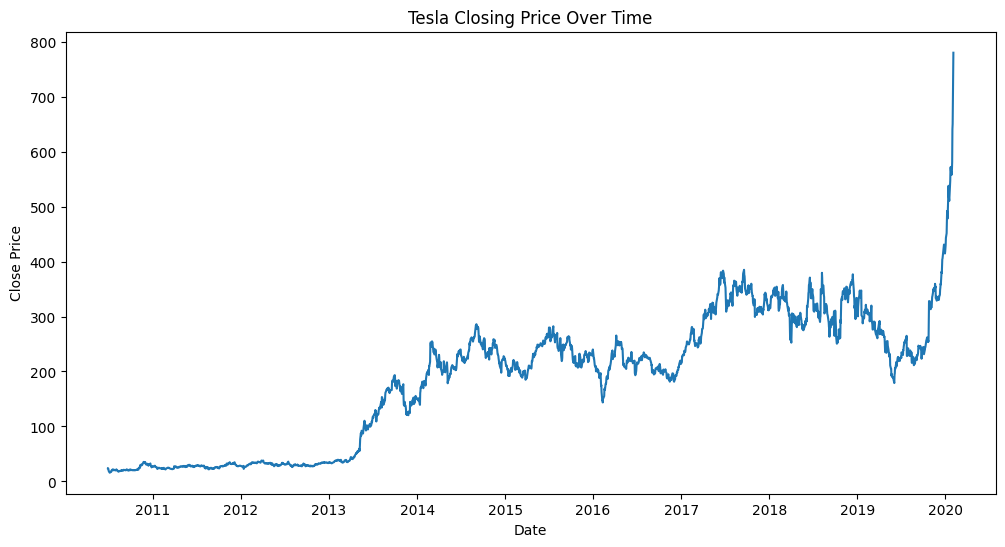

In [15]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

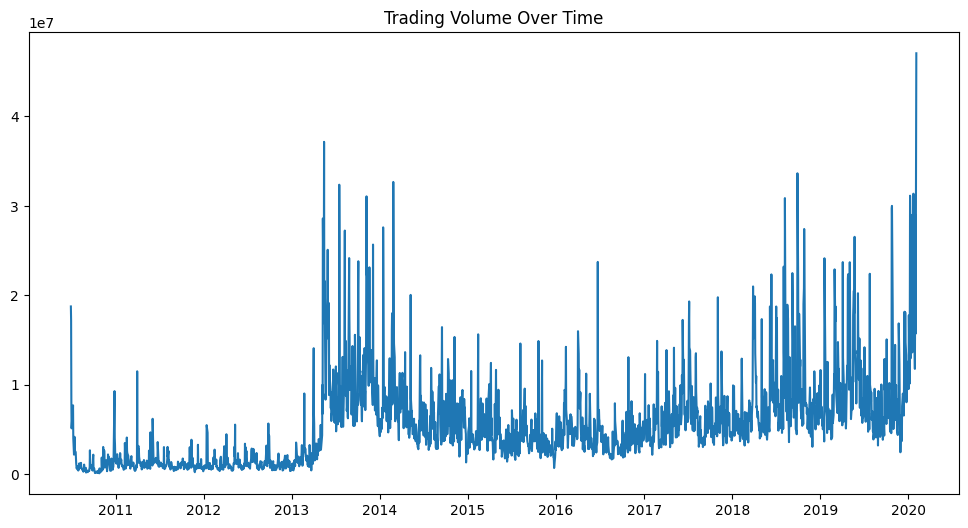

In [16]:
plt.figure(figsize=(12,6))

plt.plot(df['Volume'])

plt.title("Trading Volume Over Time")

plt.show()

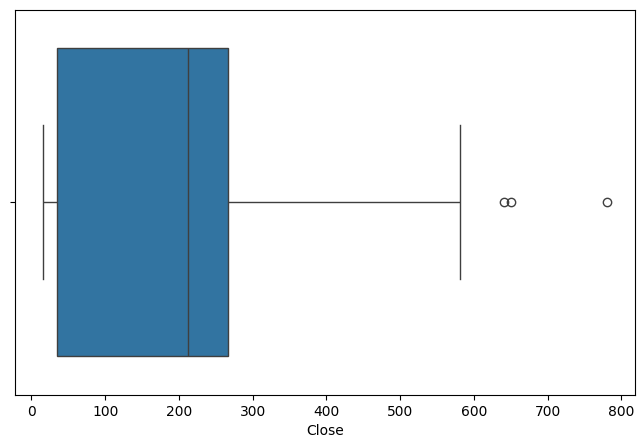

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Close'])

plt.show()

In [18]:
df['MA20'] = df['Close'].rolling(window=20).mean()

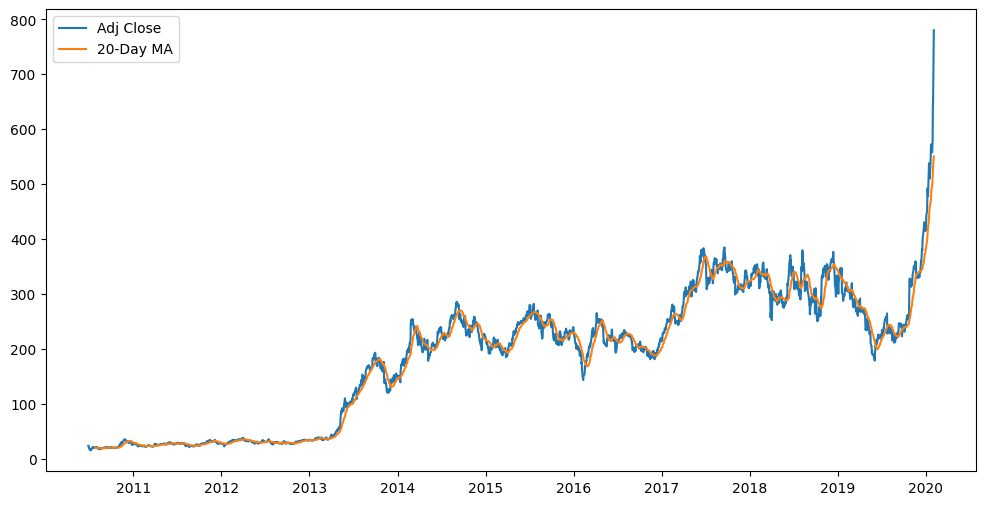

In [19]:
plt.figure(figsize=(12,6))

plt.plot(df['Adj Close'], label='Adj Close')
plt.plot(df['MA20'], label='20-Day MA')

plt.legend()
plt.show()

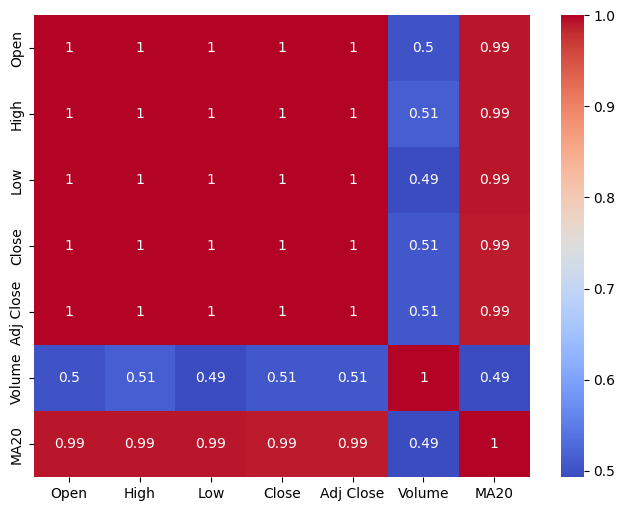

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [21]:
data = df[['Close']]

In [22]:
data.head(10)

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001
2010-07-07,15.800000
2010-07-08,17.459999
2010-07-09,17.400000
2010-07-12,17.049999


In [23]:


scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [24]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA20
Date,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN


In [25]:
scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

In [26]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA20
Date,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN


In [27]:
lookback = 60

In [28]:
def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [29]:
X, y = create_sequences(scaled_data, lookback)

In [30]:
print(X.shape)
print(y.shape)

(2356, 60, 1)
(2356, 1)


In [31]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [32]:
print(X_train.shape)
print(X_test.shape)

(1884, 60, 1)
(472, 60, 1)


In [33]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1884, 60, 1)
y_train: (1884, 1)
X_test: (472, 60, 1)
y_test: (472, 1)


In [34]:
train_data = data[:train_size]
test_data = data[train_size-lookback:]

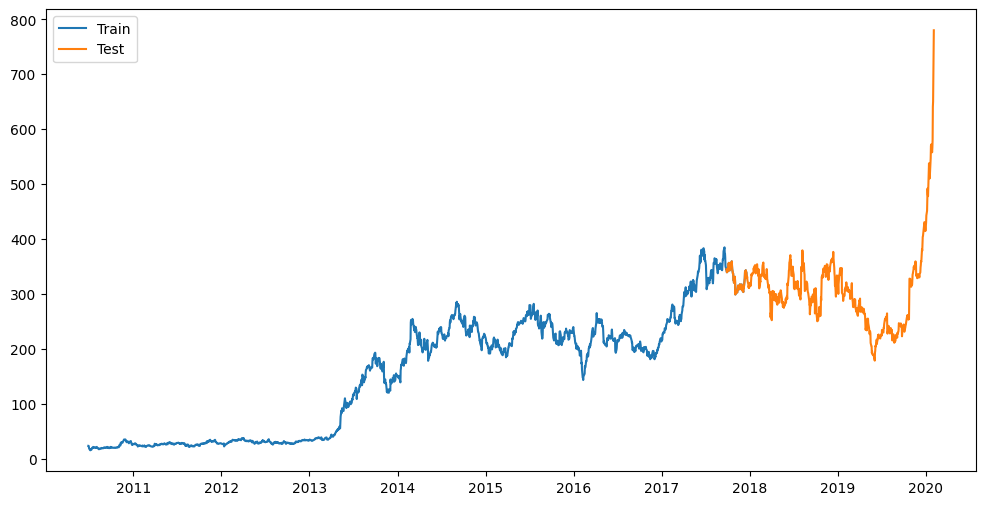

In [35]:
plt.figure(figsize=(12,6))

plt.plot(train_data.index, train_data, label='Train')
plt.plot(test_data.index, test_data, label='Test')

plt.legend()
plt.show()

In [36]:
def create_sequences(data, lookback, horizon):

    X = []
    y = []

    for i in range(lookback, len(data)-horizon+1):

        X.append(data[i-lookback:i])

        y.append(data[i+horizon-1])

    return np.array(X), np.array(y)

In [37]:
X1, y1 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=1
)

In [38]:
X5, y5 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=5
)

In [39]:
X10, y10 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=10
)

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [41]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(
    SimpleRNN(
        units=50
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [44]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [45]:
checkpoint = ModelCheckpoint(
    '../models/best_rnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [46]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [47]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())

2.16.1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [48]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
print(X_train.shape)
print(y_train.shape)

(1884, 60, 1)
(1884, 1)


In [50]:
print(X_train.dtype)
print(y_train.dtype)

float64
float64


In [51]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [52]:
import tensorflow as tf

print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [53]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0279 - val_loss: 0.0021
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0062 - val_loss: 0.0013
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - val_loss: 0.0020
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - val_loss: 3.7415e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - val_loss: 4.7026e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - val_loss: 5.0356e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 3.2677e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - val_loss: 3.2605e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 2.4051e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 5.3455e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 2.7018e-04
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 

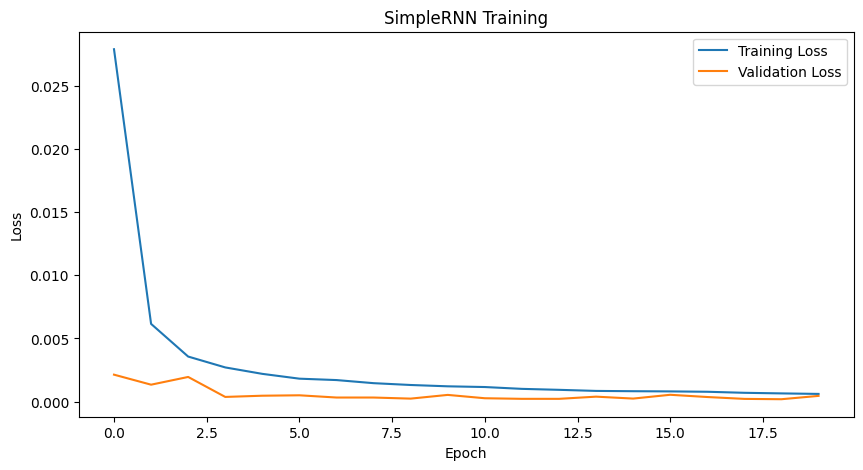

In [54]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("SimpleRNN Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [55]:
rnn_predictions = rnn_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [56]:
rnn_predictions = scaler.inverse_transform(rnn_predictions)

actual_prices = scaler.inverse_transform(y_test)

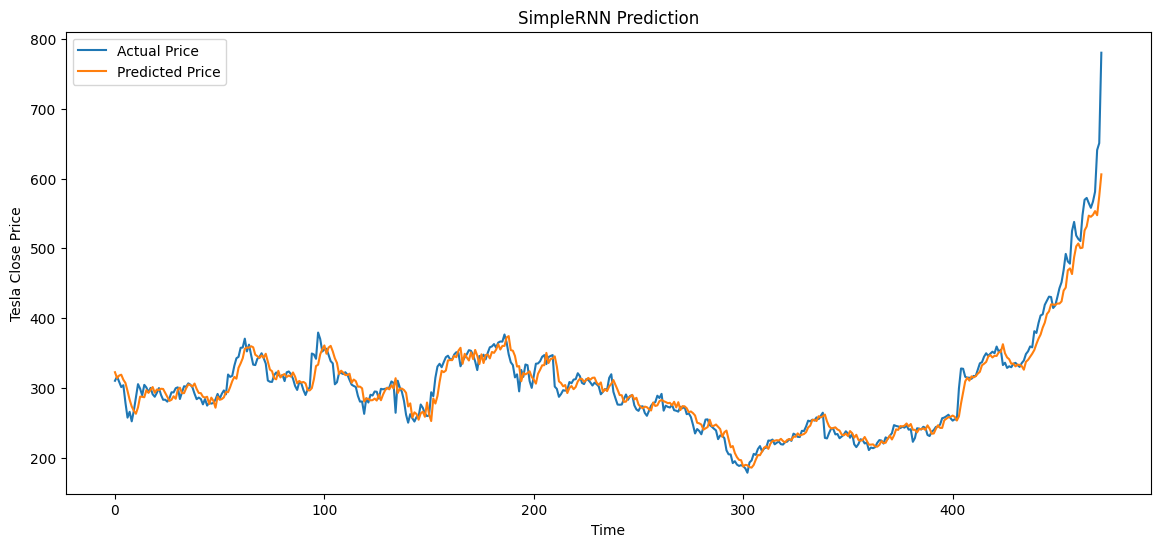

In [57]:
plt.figure(figsize=(14,6))

plt.plot(
    actual_prices,
    label='Actual Price'
)

plt.plot(
    rnn_predictions,
    label='Predicted Price'
)

plt.title("SimpleRNN Prediction")
plt.xlabel("Time")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [58]:
test_dates = data.index[-len(actual_prices):]

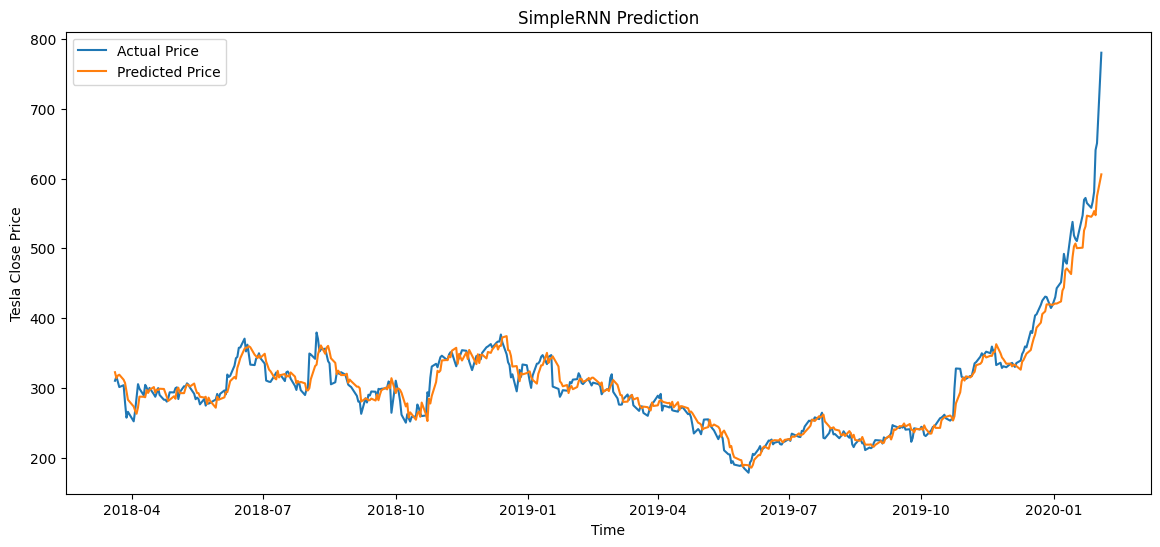

In [59]:
plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    rnn_predictions,
    label='Predicted Price'
)

plt.title("SimpleRNN Prediction")
plt.xlabel("Time")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [60]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [61]:
mse_rnn = mean_squared_error(
    actual_prices,
    rnn_predictions
)

rmse_rnn = np.sqrt(mse_rnn)

mae_rnn = mean_absolute_error(
    actual_prices,
    rnn_predictions
)

r2_rnn = r2_score(
    actual_prices,
    rnn_predictions
)

print("MSE :", mse_rnn)
print("RMSE:", rmse_rnn)
print("MAE :", mae_rnn)
print("R2  :", r2_rnn)

MSE : 305.45543205031225
RMSE: 17.477283314357305
MAE : 11.116509640389136
R2  : 0.9420305730174238


In [62]:
rnn_model.save("../models/simple_rnn_model.keras")

In [63]:
import os
print(os.listdir("../models"))

['best_rnn_model.keras', 'simple_rnn_model.keras']


In [64]:
from tensorflow.keras.layers import LSTM

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    LSTM(
        units=50
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [66]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [68]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '../models/best_lstm_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [69]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0051 - val_loss: 5.3258e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.2335e-04 - val_loss: 8.1081e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.9875e-04 - val_loss: 4.4196e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.4200e-04 - val_loss: 4.9876e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.5454e-04 - val_loss: 5.4610e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.8691e-04 - val_loss: 4.1057e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.3015e-04 - val_loss: 4.1975e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.6039e-04 - val_loss: 5.4765e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.4425e-04 - val_loss: 5.2613e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.5713e-04 - val_loss: 4.3518e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.9245e-04 - 

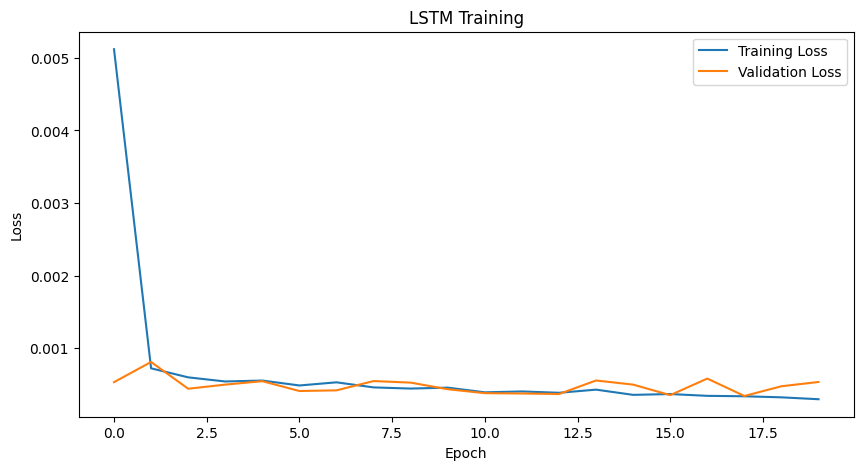

In [70]:
plt.figure(figsize=(10,5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [71]:
lstm_predictions = lstm_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [72]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

actual_prices = scaler.inverse_transform(
    y_test
)

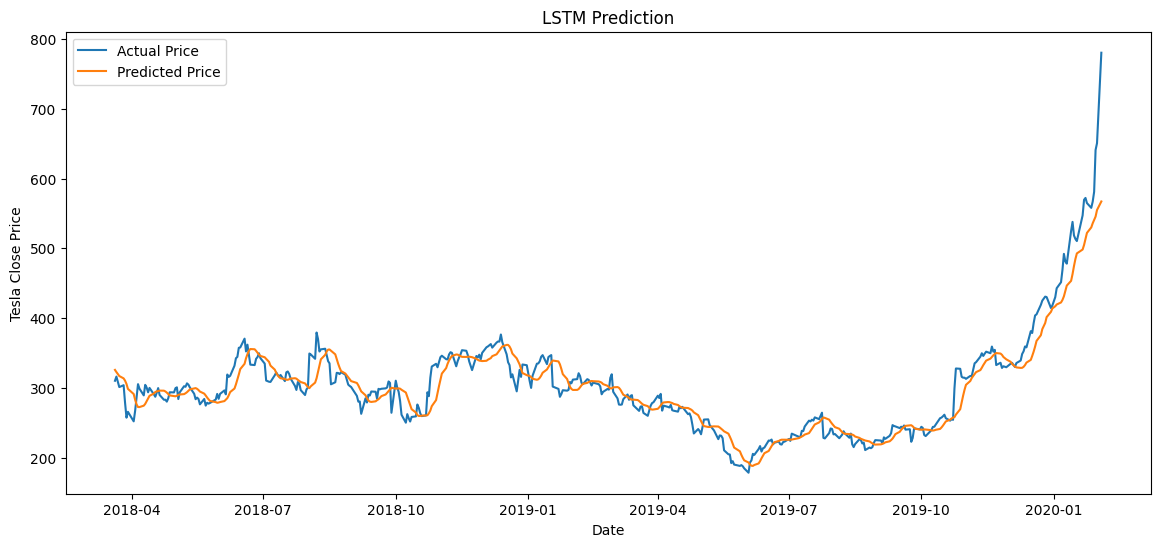

In [73]:
test_dates = data.index[-len(actual_prices):]

plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='Predicted Price'
)

plt.title("LSTM Prediction")

plt.xlabel("Date")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [74]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

mse_lstm = mean_squared_error(
    actual_prices,
    lstm_predictions
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

r2_lstm = r2_score(
    actual_prices,
    lstm_predictions
)

print("MSE :", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)
print("R2  :", r2_lstm)

MSE : 538.1788987166415
RMSE: 23.19868312462243
MAE : 15.84724173699848
R2  : 0.8978642410668312


In [75]:
lstm_model.save("../models/lstm_model.keras")

In [76]:
comparison = pd.DataFrame({
    'Model':['SimpleRNN','LSTM'],
    'MSE':[mse_rnn,mse_lstm],
    'RMSE':[rmse_rnn,rmse_lstm],
    'MAE':[mae_rnn,mae_lstm],
    'R2':[r2_rnn,r2_lstm]
})

comparison

,Model,MSE,RMSE,MAE,R2
0,SimpleRNN,305.455432,17.477283,11.116510,0.942031
1,LSTM,538.178899,23.198683,15.847242,0.897864


In [77]:
comparison.sort_values(
    by='RMSE'
)

,Model,MSE,RMSE,MAE,R2
0,SimpleRNN,305.455432,17.477283,11.116510,0.942031
1,LSTM,538.178899,23.198683,15.847242,0.897864


In [78]:
from tensorflow.keras.optimizers import Adam

In [79]:
def build_lstm_model(units, dropout_rate, learning_rate):

    model = Sequential()

    model.add(
        LSTM(
            units=units,
            return_sequences=True,
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )

    model.add(Dropout(dropout_rate))

    model.add(LSTM(units))

    model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error'
    )

    return model

In [80]:
units_list = [32, 64]

dropout_list = [0.2, 0.3]

learning_rate_list = [0.001, 0.0001]

In [81]:
results = []

In [82]:
for units in units_list:

    for dropout in dropout_list:

        for lr in learning_rate_list:

            print(
                f"Units={units}, "
                f"Dropout={dropout}, "
                f"LR={lr}"
            )

            model = build_lstm_model(
                units,
                dropout,
                lr
            )

            history = model.fit(
                X_train,
                y_train,
                epochs=10,
                batch_size=32,
                validation_split=0.1,
                verbose=0
            )

            best_val_loss = min(
                history.history['val_loss']
            )

            results.append([
                units,
                dropout,
                lr,
                best_val_loss
            ])

Units=32, Dropout=0.2, LR=0.001


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Units=32, Dropout=0.2, LR=0.0001
Units=32, Dropout=0.3, LR=0.001
Units=32, Dropout=0.3, LR=0.0001
Units=64, Dropout=0.2, LR=0.001
Units=64, Dropout=0.2, LR=0.0001
Units=64, Dropout=0.3, LR=0.001
Units=64, Dropout=0.3, LR=0.0001


In [83]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Units',
        'Dropout',
        'Learning Rate',
        'Val Loss'
    ]
)

results_df

,Units,Dropout,Learning Rate,Val Loss
0,32,0.2,0.0010,0.000427
1,32,0.2,0.0001,0.000651
2,32,0.3,0.0010,0.000429
3,32,0.3,0.0001,0.000606
4,64,0.2,0.0010,0.000376
5,64,0.2,0.0001,0.000545
6,64,0.3,0.0010,0.000371
7,64,0.3,0.0001,0.000525


In [84]:
results_df.sort_values(
    by='Val Loss'
)

,Units,Dropout,Learning Rate,Val Loss
6,64,0.3,0.0010,0.000371
4,64,0.2,0.0010,0.000376
0,32,0.2,0.0010,0.000427
2,32,0.3,0.0010,0.000429
7,64,0.3,0.0001,0.000525
5,64,0.2,0.0001,0.000545
3,32,0.3,0.0001,0.000606
1,32,0.2,0.0001,0.000651


In [85]:
best_row = results_df.sort_values(
    by='Val Loss'
).iloc[0]

best_row

Units            64.000000
Dropout           0.300000
Learning Rate     0.001000
Val Loss          0.000371
Name: 6, dtype: float64

In [86]:
final_lstm = build_lstm_model(
    units=int(best_row['Units']),
    dropout_rate=float(best_row['Dropout']),
    learning_rate=float(best_row['Learning Rate'])
)

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [87]:
history_final = final_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0051 - val_loss: 6.8632e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.7382e-04 - val_loss: 6.3505e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.1311e-04 - val_loss: 4.9915e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.1668e-04 - val_loss: 7.4425e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.8478e-04 - val_loss: 4.5935e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.9117e-04 - val_loss: 4.3879e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.3205e-04 - val_loss: 4.2903e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.1232e-04 - val_loss: 5.8101e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.8712e-04 - val_loss: 7.1568e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.6944e-04 - val_loss: 4.2271e-04


In [88]:
final_predictions = final_lstm.predict(X_test)

final_predictions = scaler.inverse_transform(
    final_predictions
)

actual_prices = scaler.inverse_transform(
    y_test
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [89]:
mse_final = mean_squared_error(
    actual_prices,
    final_predictions
)

rmse_final = np.sqrt(mse_final)

mae_final = mean_absolute_error(
    actual_prices,
    final_predictions
)

r2_final = r2_score(
    actual_prices,
    final_predictions
)

print("RMSE:", rmse_final)
print("MAE :", mae_final)
print("R2  :", r2_final)

RMSE: 33.15248245208895
MAE : 23.204007359710175
R2  : 0.7914149093954861


In [90]:
final_lstm.save(
    "../models/final_lstm_model.keras"
)

In [91]:
X1, y1 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=1
)

In [92]:
X5, y5 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=5
)

In [93]:
X10, y10 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=10
)

In [94]:
def split_data(X, y):

    train_size = int(len(X)*0.8)

    X_train = X[:train_size]
    X_test = X[train_size:]

    y_train = y[:train_size]
    y_test = y[train_size:]

    return X_train, X_test, y_train, y_test

In [95]:
X1_train, X1_test, y1_train, y1_test = split_data(X1, y1)

X5_train, X5_test, y5_train, y5_test = split_data(X5, y5)

X10_train, X10_test, y10_train, y10_test = split_data(X10, y10)

In [96]:
def build_final_model():

    model = Sequential()

    model.add(
        LSTM(
            64,
            return_sequences=True,
            input_shape=(60,1)
        )
    )

    model.add(Dropout(0.2))

    model.add(LSTM(64))

    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(0.001),
        loss='mean_squared_error'
    )

    return model

In [97]:
model_1day = build_final_model()

model_1day.fit(
    X1_train,
    y1_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0034 - val_loss: 4.9969e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.6378e-04 - val_loss: 4.7149e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.1575e-04 - val_loss: 8.3247e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.7535e-04 - val_loss: 4.5698e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.6254e-04 - val_loss: 4.1563e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.4148e-04 - val_loss: 8.0161e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.6792e-04 - val_loss: 5.4096e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.7463e-04 - val_loss: 4.6960e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.8571e-04 - val_loss: 5.8201e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.9533e-04 - val_loss: 4.0571e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.4158e-04 - val_loss: 3

In [98]:
model_1day.save(
    "../models/model_1day.keras"
)

In [99]:
pred1 = model_1day.predict(X1_test)

pred1 = scaler.inverse_transform(pred1)

actual1 = scaler.inverse_transform(y1_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [100]:
rmse_1 = np.sqrt(
    mean_squared_error(
        actual1,
        pred1
    )
)

print(rmse_1)

24.173875012318316


In [101]:
model_5day = build_final_model()

model_5day.fit(
    X5_train,
    y5_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0029 - val_loss: 7.9857e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.5682e-04 - val_loss: 7.1485e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.6794e-04 - val_loss: 8.9401e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.4668e-04 - val_loss: 9.1852e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.2227e-04 - val_loss: 6.8779e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.2706e-04 - val_loss: 6.9920e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.4934e-04 - val_loss: 6.6424e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.3392e-04 - val_loss: 9.2984e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.1165e-04 - val_loss: 0.0013
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.1199e-04 - val_loss: 0.0010
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.2311e-04 - val_loss: 6.5945e-0

In [102]:
model_5day.save(
    "../models/model_5day.keras"
)

In [103]:
pred5 = model_5day.predict(X5_test)

pred5 = scaler.inverse_transform(pred5)

actual5 = scaler.inverse_transform(y5_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [104]:
rmse_5 = np.sqrt(
    mean_squared_error(
        actual5,
        pred5
    )
)

print(rmse_5)

33.43222911603655


In [105]:
model_10day = build_final_model()

model_10day.fit(
    X10_train,
    y10_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0050 - val_loss: 8.4905e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.8127e-04 - val_loss: 8.8243e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.2285e-04 - val_loss: 8.8000e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.8584e-04 - val_loss: 0.0014
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.5716e-04 - val_loss: 8.1557e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.4353e-04 - val_loss: 9.2479e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.5918e-04 - val_loss: 0.0013
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.2582e-04 - val_loss: 0.0010
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.1847e-04 - val_loss: 9.0954e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.8432e-04 - val_loss: 8.0676e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.1539e-04 - val_loss: 8.3166e-04
Ep

In [106]:
model_10day.save(
    "../models/model_10day.keras"
)

In [107]:
pred10 = model_10day.predict(X10_test)

pred10 = scaler.inverse_transform(pred10)

actual10 = scaler.inverse_transform(y10_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [108]:
rmse_10 = np.sqrt(
    mean_squared_error(
        actual10,
        pred10
    )
)

print(rmse_10)

42.00242724188615


In [109]:
forecast_results = pd.DataFrame({

    'Forecast Horizon': [
        '1 Day',
        '5 Days',
        '10 Days'
    ],

    'RMSE': [
        rmse_1,
        rmse_5,
        rmse_10
    ]
})

forecast_results

,Forecast Horizon,RMSE
0,1 Day,24.173875
1,5 Days,33.432229
2,10 Days,42.002427


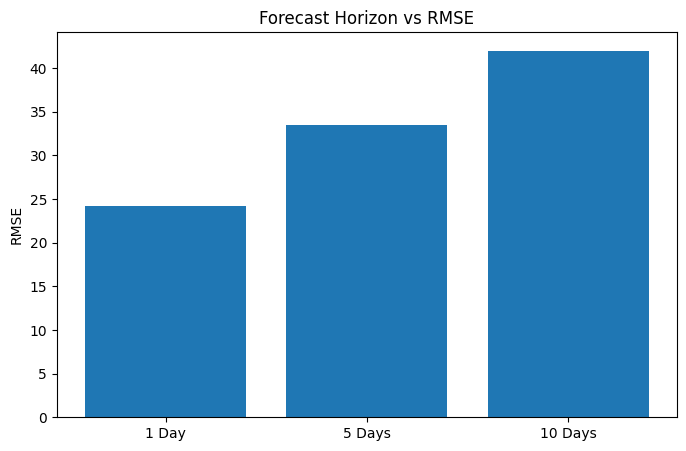

In [110]:
plt.figure(figsize=(8,5))

plt.bar(
    forecast_results['Forecast Horizon'],
    forecast_results['RMSE']
)

plt.title(
    'Forecast Horizon vs RMSE'
)

plt.ylabel('RMSE')

plt.show()

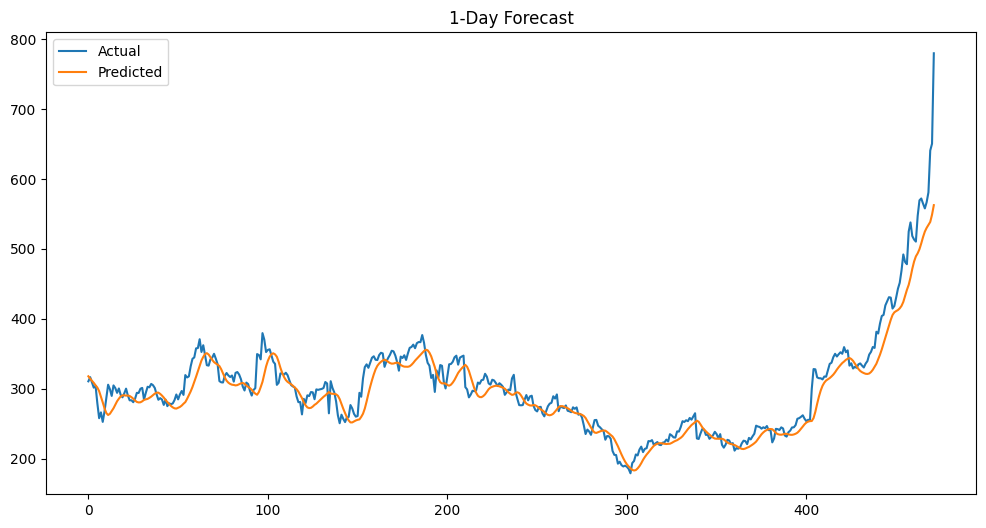

In [111]:
plt.figure(figsize=(12,6))

plt.plot(actual1, label='Actual')
plt.plot(pred1, label='Predicted')

plt.title('1-Day Forecast')

plt.legend()

plt.show()

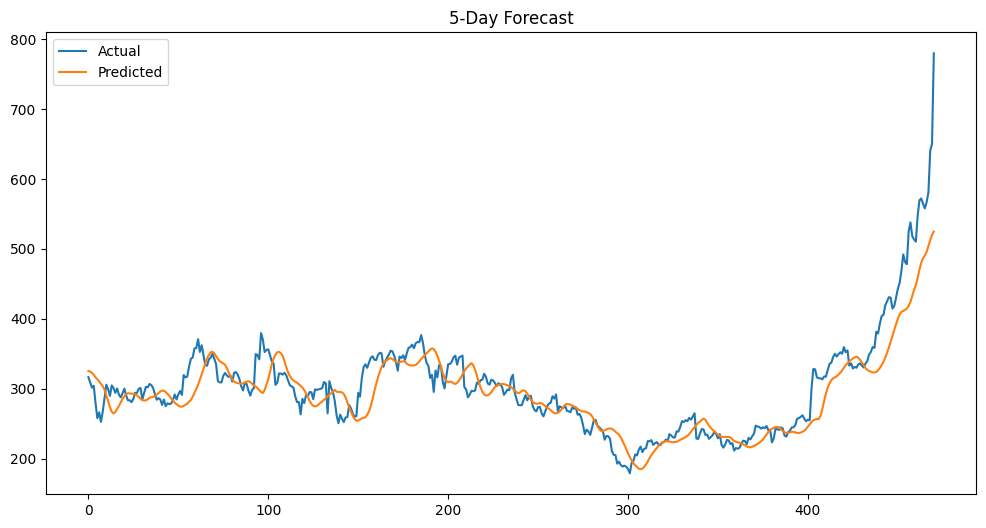

In [112]:
plt.figure(figsize=(12,6))

plt.plot(actual5, label='Actual')
plt.plot(pred5, label='Predicted')

plt.title('5-Day Forecast')

plt.legend()

plt.show()

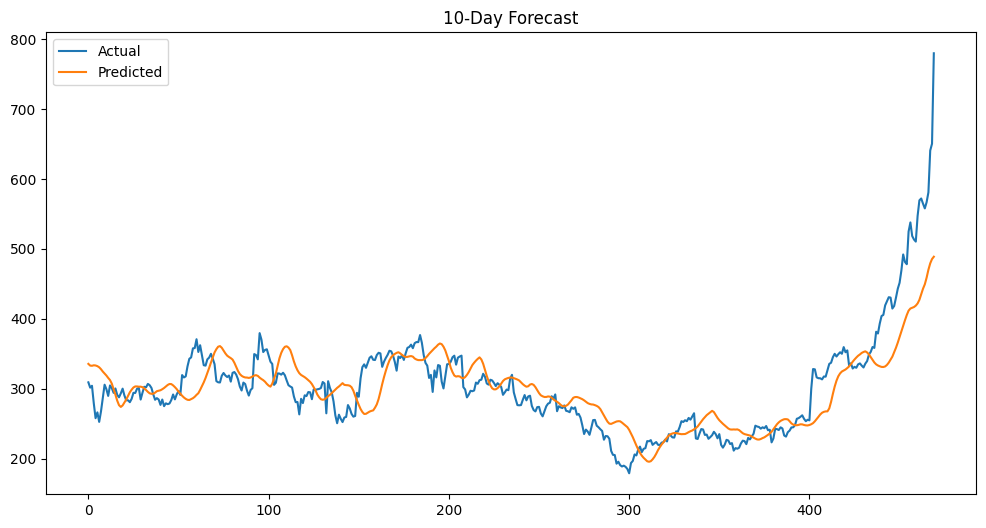

In [113]:
plt.figure(figsize=(12,6))

plt.plot(actual10, label='Actual')
plt.plot(pred10, label='Predicted')

plt.title('10-Day Forecast')

plt.legend()

plt.show()